# Olist Business Discovery - HVIA Task 01

This notebook is my technical analysis for the Olist Business Discovery task.

Goal: understand the business data, avoid wrong joins, find useful business patterns, and support a realistic HVIA solution proposal.

## 1. Load libraries and files

Main tools:
- `pandas` = tables/dataframes
- `numpy` = numeric helpers
- `matplotlib` = charts
- `Path` = file paths that work better across systems

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Put the CSV files inside a folder named data.
# This includes fallback paths so the notebook works across common local setups.
possible_data_dirs = [
    Path("data"),
    Path("../data"),
    Path("archive"),
    Path("/home/wassim/Downloads/HVIA/Task/Task1/archive"),
    Path("/mnt/data"),
]

files = {
    "orders": "olist_orders_dataset.csv",
    "customers": "olist_customers_dataset.csv",
    "order_items": "olist_order_items_dataset.csv",
    "products": "olist_products_dataset.csv",
    "sellers": "olist_sellers_dataset.csv",
    "payments": "olist_order_payments_dataset.csv",
    "reviews": "olist_order_reviews_dataset.csv",
    "geolocation": "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

DATA_DIR = None
for folder in possible_data_dirs:
    all_files_exist = all((folder / filename).exists() for filename in files.values())
    if all_files_exist:
        DATA_DIR = folder
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not find the CSV files. Put them in a folder named data, then rerun.")

print("Using data folder:", DATA_DIR)

Using data folder: /mnt/data


In [2]:
dfs = {}

for table_name, filename in files.items():
    file_path = DATA_DIR / filename
    dfs[table_name] = pd.read_csv(file_path)

orders = dfs["orders"]
customers = dfs["customers"]
order_items = dfs["order_items"]
products = dfs["products"]
sellers = dfs["sellers"]
payments = dfs["payments"]
reviews = dfs["reviews"]
geolocation = dfs["geolocation"]
category_translation = dfs["category_translation"]

## 2. First look at the tables

`shape[0]` = rows.  
`shape[1]` = columns.

This step tells me the size of each CSV before I do any analysis.

In [3]:
for table_name, df in dfs.items():
    print(table_name, "- rows:", df.shape[0], "columns:", df.shape[1])

orders - rows: 99441 columns: 8
customers - rows: 99441 columns: 5
order_items - rows: 112650 columns: 7
products - rows: 32951 columns: 9
sellers - rows: 3095 columns: 4
payments - rows: 103886 columns: 5
reviews - rows: 99224 columns: 7
geolocation - rows: 1000163 columns: 5
category_translation - rows: 71 columns: 2


## 3. Understand row level

Row level means: **what does one row represent?**

This matters because wrong joins can duplicate money, reviews, or freight values.

In [4]:
print("ORDERS")
print("Rows:", orders.shape[0])
print("Unique order_id:", orders["order_id"].nunique())
print()

print("ORDER ITEMS")
print("Rows:", order_items.shape[0])
print("Unique order_id:", order_items["order_id"].nunique())
print()

print("PAYMENTS")
print("Rows:", payments.shape[0])
print("Unique order_id:", payments["order_id"].nunique())
print()

print("REVIEWS")
print("Rows:", reviews.shape[0])
print("Unique order_id:", reviews["order_id"].nunique())

ORDERS
Rows: 99441
Unique order_id: 99441

ORDER ITEMS
Rows: 112650
Unique order_id: 98666

PAYMENTS
Rows: 103886
Unique order_id: 99440

REVIEWS
Rows: 99224
Unique order_id: 98673


### Row-level interpretation

- `orders`: rows equal unique `order_id`, so it is order-level.
- `order_items`: more rows than unique `order_id`, so some orders have multiple item rows.
- `payments`: more rows than unique `order_id`, so some orders have multiple payment rows.
- `reviews`: not every order has a review, and some orders may have more than one review row.

Because of this, I should aggregate `order_items`, `payments`, and `reviews` before joining them to `orders`.

In [5]:
order_items["order_id"].value_counts().head(10)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
73c8ab38f07dc94389065f7eba4f297a    14
9bdc4d4c71aa1de4606060929dee888c    14
37ee401157a3a0b28c9c6d0ed8c3b24b    13
637617b3ffe9e2f7a2411243829226d0    12
2c2a19b5703863c908512d135aa6accc    12
Name: count, dtype: int64

The output above shows the orders that appear most often in `order_items`. If an order appears 21 times, that means it has 21 item rows.

In [6]:
example_order_id = order_items["order_id"].value_counts().index[0]
order_items[order_items["order_id"] == example_order_id]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57298,8272b63d03f5f79c56e9e4120aec44ef,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57299,8272b63d03f5f79c56e9e4120aec44ef,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57301,8272b63d03f5f79c56e9e4120aec44ef,5,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57302,8272b63d03f5f79c56e9e4120aec44ef,6,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57303,8272b63d03f5f79c56e9e4120aec44ef,7,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57304,8272b63d03f5f79c56e9e4120aec44ef,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57305,8272b63d03f5f79c56e9e4120aec44ef,9,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57306,8272b63d03f5f79c56e9e4120aec44ef,10,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89


## 4. Customer ID vs customer unique ID

`customer_id` is connected to an order.  
`customer_unique_id` is better for repeat-customer analysis.

In [7]:
print("CUSTOMERS")
print("Rows:", customers.shape[0])
print("Unique customer_id:", customers["customer_id"].nunique())
print("Unique customer_unique_id:", customers["customer_unique_id"].nunique())

CUSTOMERS
Rows: 99441
Unique customer_id: 99441
Unique customer_unique_id: 96096


Interpretation: `customer_id` is almost like an order/customer transaction ID, while `customer_unique_id` helps identify the same customer across multiple orders.

## 5. Clean dates

The date columns start as text. I convert them to real datetime columns so I can calculate delivery days and late deliveries.

In [8]:
orders_clean = orders.copy()

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for column in date_columns:
    orders_clean[column] = pd.to_datetime(orders_clean[column], errors="coerce")

orders_clean[date_columns].head()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


## 6. Add English product categories

The product categories are in Portuguese, so I merge the translation table onto the product table.

In [9]:
products_clean = products.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

products_clean["category"] = products_clean["product_category_name_english"].fillna(products_clean["product_category_name"])
products_clean["category"] = products_clean["category"].fillna("unknown")

products_clean[["product_id", "product_category_name", "category"]].head()

,product_id,product_category_name,category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares


## 7. Join items to products and sellers

`order_items` tells me what was sold.  
`products` gives me the category.  
`sellers` gives me seller location.

In [10]:
items = order_items.merge(
    products_clean[["product_id", "product_category_name", "category"]],
    on="product_id",
    how="left"
)

items = items.merge(
    sellers[["seller_id", "seller_city", "seller_state"]],
    on="seller_id",
    how="left"
)

items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,category,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools,loanda,PR


## 8. Aggregate item rows to order level

This is important. `order_items` can have many rows per order.  
Before joining to `orders`, I summarize it so every order has one row.

In [11]:
items_order = (
    items.groupby("order_id")
    .agg(
        item_count=("order_item_id", "count"),
        product_count=("product_id", "nunique"),
        seller_count=("seller_id", "nunique"),
        item_price=("price", "sum"),
        freight_value=("freight_value", "sum"),
    )
    .reset_index()
)

items_order.head()

,order_id,item_count,product_count,seller_count,item_price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14


For category analysis, an order can contain more than one product/category.  
For a simple order-level table, I choose the category with the highest item price as the order's primary category.

In [12]:
category_by_order = items.groupby(["order_id", "category"])["price"].sum().reset_index()
category_by_order = category_by_order.sort_values(["order_id", "price"], ascending=[True, False])

primary_category = category_by_order.drop_duplicates("order_id")[["order_id", "category"]]
primary_category = primary_category.rename(columns={"category": "primary_category"})

items_order = items_order.merge(primary_category, on="order_id", how="left")
items_order.head()

,order_id,item_count,product_count,seller_count,item_price,freight_value,primary_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,garden_tools


## 9. Aggregate payments and reviews

Same idea: make one row per order before joining.

In [13]:
def combine_payment_methods(values):
    unique_values = values.dropna().unique()
    unique_values = sorted(unique_values)
    return ", ".join(unique_values)

def has_any_comment(values):
    return values.notna().any()

payments_order = (
    payments.groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        payment_rows=("payment_sequential", "count"),
        max_installments=("payment_installments", "max"),
    )
    .reset_index()
)

payment_methods = (
    payments.groupby("order_id")["payment_type"]
    .apply(combine_payment_methods)
    .reset_index(name="payment_methods")
)

payments_order = payments_order.merge(payment_methods, on="order_id", how="left")

reviews_order = (
    reviews.groupby("order_id")
    .agg(
        review_score=("review_score", "mean"),
        review_count=("review_id", "count"),
        has_review_comment=("review_comment_message", has_any_comment),
    )
    .reset_index()
)

payments_order.head(), reviews_order.head()

(                           order_id  payment_value  payment_rows  \
 0  00010242fe8c5a6d1ba2dd792cb16214          72.19             1   
 1  00018f77f2f0320c557190d7a144bdd3         259.83             1   
 2  000229ec398224ef6ca0657da4fc703e         216.87             1   
 3  00024acbcdf0a6daa1e931b038114c75          25.78             1   
 4  00042b26cf59d7ce69dfabb4e55b4fd9         218.04             1   
 
    max_installments payment_methods  
 0                 2     credit_card  
 1                 3     credit_card  
 2                 5     credit_card  
 3                 2     credit_card  
 4                 3     credit_card  ,
                            order_id  review_score  review_count  \
 0  00010242fe8c5a6d1ba2dd792cb16214          5.00             1   
 1  00018f77f2f0320c557190d7a144bdd3          4.00             1   
 2  000229ec398224ef6ca0657da4fc703e          5.00             1   
 3  00024acbcdf0a6daa1e931b038114c75          4.00             1   
 4  00042

## 10. Build the main analysis table

Now I merge everything onto `orders_clean`.  
The goal is one clean table where **one row = one order**.

In [14]:
order_analysis = (
    orders_clean
    .merge(customers, on="customer_id", how="left")
    .merge(items_order, on="order_id", how="left")
    .merge(payments_order, on="order_id", how="left")
    .merge(reviews_order, on="order_id", how="left")
)

print("Rows in orders:", orders_clean.shape[0])
print("Rows in order_analysis:", order_analysis.shape[0])
order_analysis.head()

Rows in orders: 99441
Rows in order_analysis: 99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_count,product_count,seller_count,item_price,freight_value,primary_category,payment_value,payment_rows,max_installments,payment_methods,review_score,review_count,has_review_comment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,1.00,1.00,29.99,8.72,housewares,38.71,3.00,1.00,"credit_card, voucher",4.00,1.00,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,1.00,1.00,118.70,22.76,perfumery,141.46,1.00,1.00,boleto,4.00,1.00,True
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,1.00,1.00,159.90,19.22,auto,179.12,1.00,3.00,credit_card,5.00,1.00,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.00,1.00,1.00,45.00,27.20,pet_shop,72.20,1.00,1.00,credit_card,5.00,1.00,True
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.00,1.00,1.00,19.90,8.72,stationery,28.62,1.00,1.00,credit_card,5.00,1.00,False


If the row count stayed the same as `orders`, the merge did not accidentally duplicate orders.

## 11. Create business metric columns

These columns help answer business questions:
- delivery time
- delay days
- late / on-time
- purchase month
- freight ratio

In [15]:
order_analysis["delivery_days"] = (
    order_analysis["order_delivered_customer_date"] - order_analysis["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

order_analysis["estimated_delivery_days"] = (
    order_analysis["order_estimated_delivery_date"] - order_analysis["order_purchase_timestamp"]
).dt.total_seconds() / (60 * 60 * 24)

order_analysis["delay_days"] = (
    order_analysis["order_delivered_customer_date"] - order_analysis["order_estimated_delivery_date"]
).dt.total_seconds() / (60 * 60 * 24)

order_analysis["is_late"] = order_analysis["delay_days"] > 0
order_analysis["purchase_month"] = order_analysis["order_purchase_timestamp"].dt.to_period("M").astype(str)

order_analysis["freight_ratio"] = order_analysis["freight_value"] / order_analysis["item_price"]
order_analysis.loc[~np.isfinite(order_analysis["freight_ratio"]), "freight_ratio"] = np.nan

order_analysis[["order_id", "delivery_days", "delay_days", "is_late", "freight_ratio"]].head()

,order_id,delivery_days,delay_days,is_late,freight_ratio
0,e481f51cbdc54678b7cc49136f2d6af7,8.44,-7.11,False,0.29
1,53cdb2fc8bc7dce0b6741e2150273451,13.78,-5.36,False,0.19
2,47770eb9100c2d0c44946d9cf07ec65d,9.39,-17.25,False,0.12
3,949d5b44dbf5de918fe9c16f97b45f8a,13.21,-12.98,False,0.60
4,ad21c59c0840e6cb83a9ceb5573f8159,2.87,-9.24,False,0.44


## 12. Business overview metrics

In [16]:
delivered = order_analysis[order_analysis["order_status"] == "delivered"].copy()

summary_metrics = pd.DataFrame([
    ["total_orders", len(order_analysis)],
    ["delivered_orders", len(delivered)],
    ["cancelled_orders", int((order_analysis["order_status"] == "canceled").sum())],
    ["unavailable_orders", int((order_analysis["order_status"] == "unavailable").sum())],
    ["date_min", order_analysis["order_purchase_timestamp"].min()],
    ["date_max", order_analysis["order_purchase_timestamp"].max()],
    ["total_payment_value", round(order_analysis["payment_value"].sum(), 2)],
    ["average_payment_value", round(order_analysis["payment_value"].mean(), 2)],
    ["unique_customers", order_analysis["customer_unique_id"].nunique()],
    ["unique_sellers", items["seller_id"].nunique()],
    ["unique_categories", items["category"].nunique()],
    ["average_review_score", round(order_analysis["review_score"].mean(), 2)],
    ["average_delivery_days_delivered_orders", round(delivered["delivery_days"].mean(), 2)],
    ["late_delivery_rate_delivered_orders", round(delivered["is_late"].mean() * 100, 2)],
    ["late_order_average_review_score", round(delivered.loc[delivered["is_late"], "review_score"].mean(), 2)],
    ["on_time_average_review_score", round(delivered.loc[~delivered["is_late"], "review_score"].mean(), 2)],
    ["repeat_customer_rate", round((customers["customer_unique_id"].value_counts() > 1).mean() * 100, 2)],
], columns=["metric", "value"])

summary_metrics

,metric,value
0,total_orders,99441
1,delivered_orders,96478
2,cancelled_orders,625
3,unavailable_orders,609
4,date_min,2016-09-04 21:15:19
5,date_max,2018-10-17 17:30:18
6,total_payment_value,"16,008,872.12"
7,average_payment_value,160.99
8,unique_customers,96096
9,unique_sellers,3095


## 13. Core analysis charts and tables

In [17]:
order_analysis["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

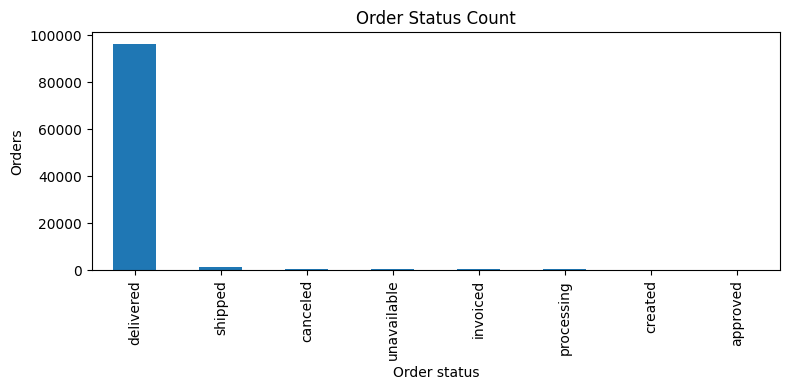

In [18]:
order_analysis["order_status"].value_counts().plot(kind="bar", figsize=(8, 4))
plt.title("Order Status Count")
plt.xlabel("Order status")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

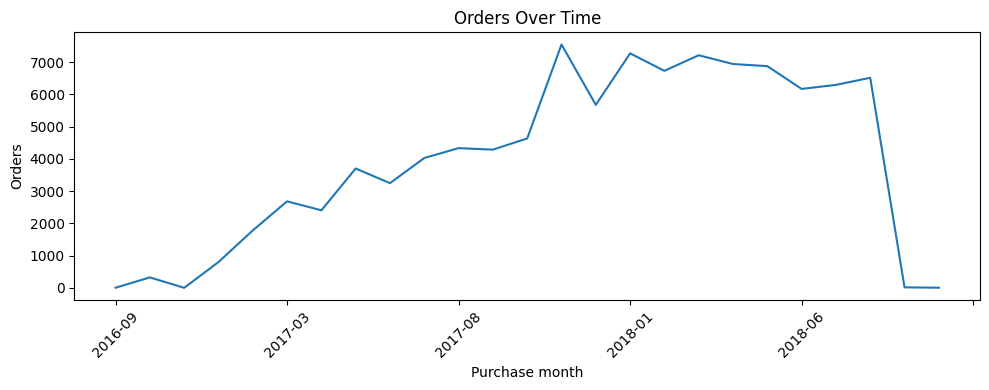

In [19]:
monthly_orders = order_analysis.groupby("purchase_month").size().reset_index(name="orders")

monthly_orders.plot(x="purchase_month", y="orders", kind="line", figsize=(10, 4), legend=False)
plt.title("Orders Over Time")
plt.xlabel("Purchase month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
top_customer_states = order_analysis["customer_state"].value_counts().head(10)
top_customer_states

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

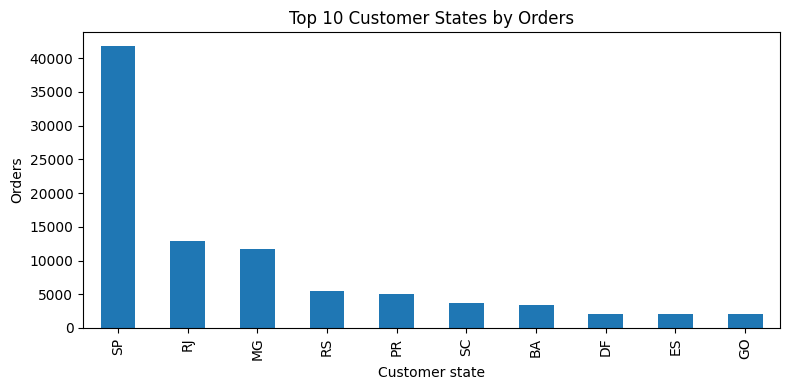

In [21]:
top_customer_states.plot(kind="bar", figsize=(8, 4))
plt.title("Top 10 Customer States by Orders")
plt.xlabel("Customer state")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

In [22]:
category_summary = (
    items.groupby("category")
    .agg(
        item_rows=("order_id", "count"),
        unique_orders=("order_id", "nunique"),
        item_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        avg_price=("price", "mean"),
    )
    .reset_index()
)

category_summary["freight_ratio"] = category_summary["freight_value"] / category_summary["item_revenue"]

top_categories_revenue = category_summary.sort_values("item_revenue", ascending=False).head(10)
top_categories_revenue

,category,item_rows,unique_orders,item_revenue,freight_value,avg_price,freight_ratio
43,health_beauty,9670,8836,"1,258,681.34","182,566.73",130.16,0.15
73,watches_gifts,5991,5624,"1,205,005.68","100,535.93",201.14,0.08
7,bed_bath_table,11115,9417,"1,036,988.68","204,693.04",93.30,0.20
67,sports_leisure,8641,7720,"988,048.97","168,607.51",114.34,0.17
15,computers_accessories,7827,6689,"911,954.32","147,318.08",116.51,0.16
39,furniture_decor,8334,6449,"729,762.49","172,749.30",87.56,0.24
20,cool_stuff,3796,3632,"635,290.85","84,039.10",167.36,0.13
49,housewares,6964,5884,"632,248.66","146,149.11",90.79,0.23
5,auto,4235,3897,"592,720.11","92,664.21",139.96,0.16
42,garden_tools,4347,3518,"485,256.46","98,962.75",111.63,0.20


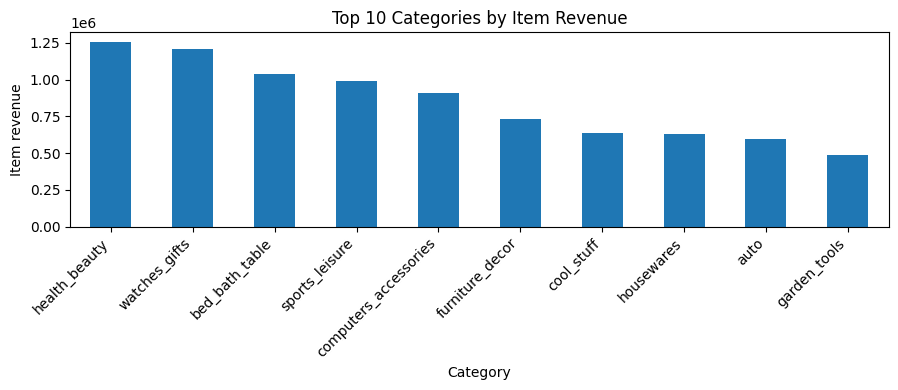

In [23]:
top_categories_revenue.set_index("category")["item_revenue"].plot(kind="bar", figsize=(9, 4))
plt.title("Top 10 Categories by Item Revenue")
plt.xlabel("Category")
plt.ylabel("Item revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
order_analysis["review_score"].value_counts().sort_index()

review_score
1.00    11316
1.50        8
2.00     3125
2.50       34
3.00     8136
3.33        1
3.50       25
4.00    19018
4.33        1
4.50       54
5.00    56955
Name: count, dtype: int64

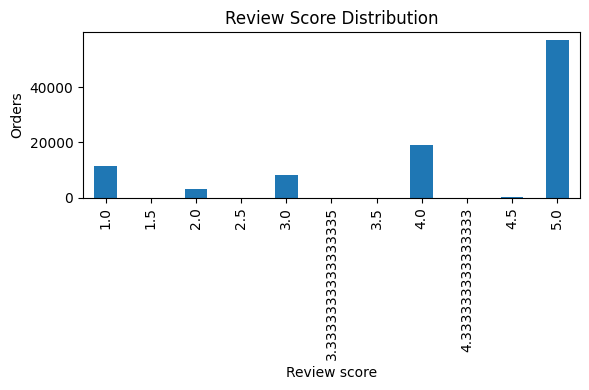

In [25]:
order_analysis["review_score"].dropna().value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("Review Score Distribution")
plt.xlabel("Review score")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

In [26]:
late_summary = (
    delivered.assign(delivery_status=np.where(delivered["is_late"], "Late", "On time / early"))
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "count"),
        average_review_score=("review_score", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_delay_days=("delay_days", "mean"),
    )
    .reset_index()
)

late_summary

,delivery_status,orders,average_review_score,average_delivery_days,average_delay_days
0,Late,7826,2.57,31.52,9.55
1,On time / early,88652,4.29,10.88,-13.01


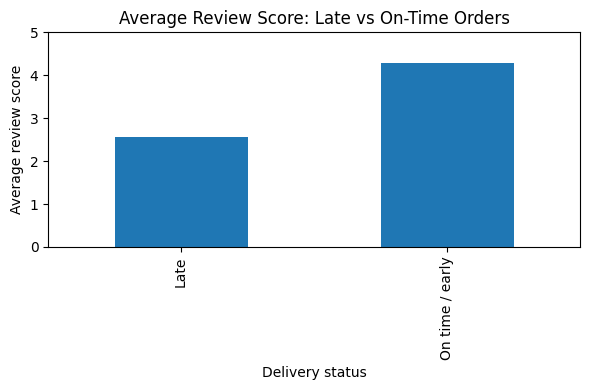

In [27]:
late_summary.set_index("delivery_status")["average_review_score"].plot(kind="bar", figsize=(6, 4))
plt.title("Average Review Score: Late vs On-Time Orders")
plt.xlabel("Delivery status")
plt.ylabel("Average review score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [28]:
state_delivery = (
    delivered.groupby("customer_state")
    .agg(
        orders=("order_id", "count"),
        average_delivery_days=("delivery_days", "mean"),
        late_rate=("is_late", "mean"),
        average_review_score=("review_score", "mean"),
    )
    .reset_index()
)

state_delivery["late_rate_percent"] = state_delivery["late_rate"] * 100

state_delivery[state_delivery["orders"] >= 100].sort_values("late_rate_percent", ascending=False).head(10)

,customer_state,orders,average_delivery_days,late_rate,average_review_score,late_rate_percent
1,AL,397,24.54,0.24,3.85,23.93
9,MA,717,21.57,0.20,3.83,19.67
16,PI,476,19.46,0.16,3.99,15.97
5,CE,1279,21.27,0.15,3.94,15.32
24,SE,335,21.52,0.15,3.91,15.22
4,BA,3256,19.34,0.14,3.93,14.04
18,RJ,12350,15.31,0.13,3.97,13.47
26,TO,274,17.66,0.13,4.15,12.77
13,PA,946,23.77,0.12,3.91,12.37
7,ES,1995,15.79,0.12,4.08,12.23


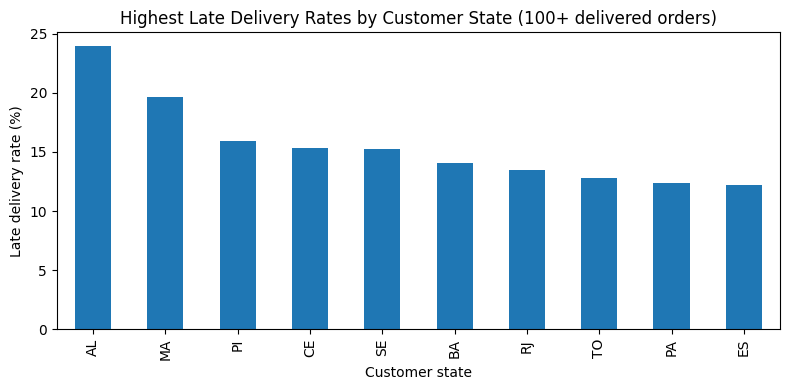

In [29]:
state_delivery_filtered = state_delivery[state_delivery["orders"] >= 100].copy()
state_delivery_filtered.sort_values("late_rate_percent", ascending=False).head(10).set_index("customer_state")["late_rate_percent"].plot(kind="bar", figsize=(8, 4))
plt.title("Highest Late Delivery Rates by Customer State (100+ delivered orders)")
plt.xlabel("Customer state")
plt.ylabel("Late delivery rate (%)")
plt.tight_layout()
plt.show()

In [30]:
freight_by_category = category_summary[category_summary["unique_orders"] >= 1000]
freight_by_category = freight_by_category.sort_values("freight_ratio", ascending=False).head(10)
freight_by_category[["category", "unique_orders", "item_revenue", "freight_value", "freight_ratio"]]

,category,unique_orders,item_revenue,freight_value,freight_ratio
26,electronics,2550,"160,246.74","46,578.32",0.29
57,office_furniture,1273,"273,960.70","68,571.95",0.25
39,furniture_decor,6449,"729,762.49","172,749.30",0.24
49,housewares,5884,"632,248.66","146,149.11",0.23
70,telephony,4199,"323,667.53","71,215.79",0.22
53,luggage_accessories,1034,"140,429.98","30,445.23",0.22
28,fashion_bags_accessories,1864,"152,823.54","31,450.00",0.21
42,garden_tools,3518,"485,256.46","98,962.75",0.20
68,stationery,2311,"230,943.23","46,798.48",0.20
7,bed_bath_table,9417,"1,036,988.68","204,693.04",0.20


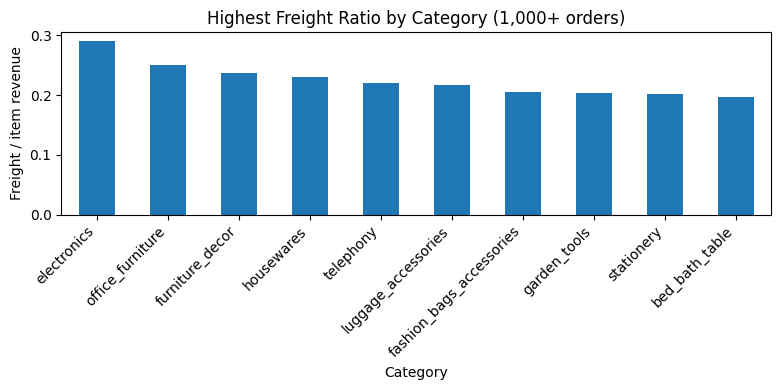

In [31]:
freight_by_category.set_index("category")["freight_ratio"].plot(kind="bar", figsize=(8, 4))
plt.title("Highest Freight Ratio by Category (1,000+ orders)")
plt.xlabel("Category")
plt.ylabel("Freight / item revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 14. Main insights

1. Most orders were delivered, but delivery timing still matters because late orders had much lower review scores than on-time/early orders.
2. Demand is highly concentrated in a few states, especially SP, RJ, and MG.
3. Category performance is not only about revenue; some categories also have higher freight burden.
4. Repeat customer rate is low in this dataset, so customer experience and first-order satisfaction are important.
5. A useful HVIA opportunity is a logistics + customer satisfaction intelligence dashboard that connects delivery timing, seller performance, freight, location, and reviews.

## 15. Suggested HVIA solution

**Logistics & Customer Satisfaction Intelligence Dashboard**

What it would monitor:
- late delivery rate
- average delivery days
- review score impact
- seller performance
- state/location performance
- category freight burden
- risky seller/category/location combinations

The goal is to help Olist identify operational problems earlier and support sellers more effectively.